# Trends in contraception prescribing in England, 2014–2025

### Introduction

This notebook has been prepared in response to a data request from a journalist, who asked what notable long-term trends we see in contraceptive prescribing in England, in particular, the marked fall in emergency contraception items since 2021. They want to compare against data from further back than the OpenPrescribing website shows by default, so that the recent decline could be checked against a pre-pandemic baseline rather than just the last few years, since the pandemic disrupted contraceptive choices for many people.

There are two parts to this:

- extract a longer run of data than the OpenPrescribing website shows, so that recent years can be compared against a pre-pandemic baseline
- work out whether the fall in emergency contraception items since 2021 is a genuine decline, or a return to normal after a pandemic-era distortion

**Limitations:**
This dataset does not include contraception provided by sexual and reproductive health (SRH) clinics, bought over the counter in pharmacies, supplied free by pharmacies under NHS or local schemes, prescribed privately, or supplied by hospitals. 


### Plan:

1. Extract contraceptive prescribing data from 2014 to the end of 2025
2. Break it down by type of contraception (BNF subparagraph)
3. Plot the trends
4. Look at emergency contraception month by month, so we can see the shape of the pandemic period rather than just yearly averages
5. Pull the findings together for discussion.

<a id='setup'></a>
### Setting up our tools

Here we load the software libraries this notebook relies on. 

In [1]:
# Import the libraries we need:
from ebmdatalab import bq                  # Connects us to the prescribing database
import pandas as pd                        # Our main tool for handling data tables
import matplotlib.pyplot as plt            # Creates charts and graphs
import matplotlib.ticker as mtick          # Helps format chart axes (e.g. adding % signs)
import os                                  # Manages file paths

# This setting ensures we can see full product names in our results
pd.set_option('display.max_colwidth', None)

### Extracting the data (2014–2025)

Medicines in this dataset are organised using the British National Formulary (BNF) coding hierarchy, which groups medicines by what they are used for. Contraceptives sit in chapter 7.3, so we can capture every contraceptive product by asking for all prescriptions whose BNF code starts with `0703`. Within chapter 7.3, products are further divided into named groups called *subparagraphs*, for example "Combined hormonal contraceptives" or "Emergency contraception.


### How much contraception is prescribed each year overall?

Before splitting anything by type, the simplest question: is total contraceptive prescribing in English primary care going up or down?. 

In [2]:
sql_all_contraceptives = """
SELECT
  EXTRACT(YEAR FROM rx.month) AS year,
    SUM(rx.items) AS items
FROM `ebmdatalab.hscic.normalised_prescribing` AS rx
WHERE month >= '2014-01-01' AND month < '2026-01-01'
  AND bnf_code LIKE '0703%'
GROUP BY year
ORDER BY year ASC
"""

all_contraceptives = bq.cached_read(
    sql_all_contraceptives,
    csv_path=os.path.join('..', 'data', 'contraceptives', 'all_contraceptives_2014_2025.csv')
)

In [3]:
display(all_contraceptives)

,year,items
0,2014,8635416
1,2015,8589636
2,2016,8550894
3,2017,8390755
4,2018,8258274
5,2019,8119477
6,2020,7803067
7,2021,7600402
8,2022,7325064
9,2023,7047397


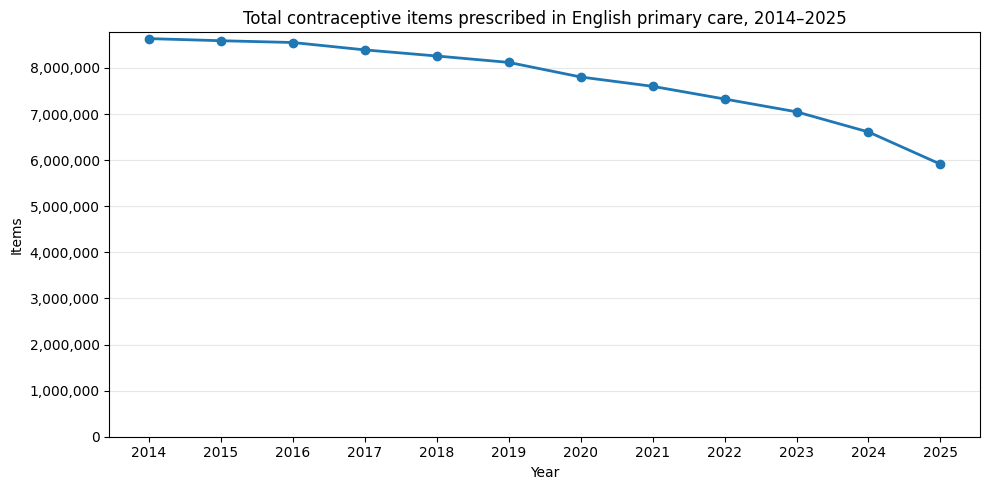

In [4]:
ax = all_contraceptives.plot(
    x='year',
    y='items',
    figsize=(10, 5),
    marker='o',
    linewidth=2,
    legend=False
)

ax.set_title('Total contraceptive items prescribed in English primary care, 2014–2025')
ax.set_xlabel('Year')
ax.set_ylabel('Items')

# Show values such as 2,000,000 instead of 1e6
ax.yaxis.set_major_formatter(
    mtick.StrMethodFormatter('{x:,.0f}')
)

# Start the y-axis at zero
ax.set_ylim(bottom=0)

# Show every year on the x-axis
ax.set_xticks(all_contraceptives['year'])

ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

That's a clear downward trend that predates covid.

### Let's look at the breakdowns by contraception type 

This will help us see which categories dominate prescribing and whether the decline in the total is broad-based or driven by particular contraception types.

Extract the data with subparagraph category

In [5]:
sql_all_contraceptives_rx_by_subparagraph = """
SELECT
  EXTRACT(YEAR FROM rx.month) AS year,
  bnf.subpara AS category,
  SUM(rx.items) AS items
FROM `ebmdatalab.hscic.normalised_prescribing` AS rx
JOIN `ebmdatalab.hscic.bnf` AS bnf
  ON rx.bnf_code = bnf.presentation_code
WHERE month >= '2014-01-01' AND month < '2026-01-01'
  AND bnf_code LIKE '0703%'
GROUP BY year, category
ORDER BY year ASC, category
"""

all_contraceptives_rx_by_subparagraph = bq.cached_read(
    sql_all_contraceptives_rx_by_subparagraph,
    csv_path=os.path.join('..', 'data', 'contraceptives', 'all_contraceptives_rx_by_subparagraph_2014_2025.csv')
)

In [6]:
display(all_contraceptives_rx_by_subparagraph.head(10))

,year,category,items
0,2014,Combined hormonal contraceptives,4606974
1,2014,Combined hormonal systems,18837
2,2014,Emergency contraception,195783
3,2014,Intra-uterine progestogen-only device,132542
4,2014,Oral progestogen-only contraceptives,2564088
5,2014,Parenteral progestogen-only contraceptives,1113565
6,2014,Spermicidal contraceptives,3627
7,2015,Combined hormonal contraceptives,4463799
8,2015,Combined hormonal systems,19842
9,2015,Emergency contraception,178921


Let's pivot the data to make it easier to plot. 

In [7]:
# One row per year, one column per contraceptive type
items_by_category = all_contraceptives_rx_by_subparagraph.pivot(
    index='year', columns='category', values='items'
)

display(items_by_category)

category,Combined hormonal contraceptives,Combined hormonal systems,Emergency contraception,Intra-uterine progestogen-only device,Oral progestogen-only contraceptives,Parenteral progestogen-only contraceptives,Spermicidal contraceptives
year,,,,,,,
2014,4606974,18837,195783,132542,2564088,1113565,3627
2015,4463799,19842,178921,126451,2711034,1086449,3140
2016,4288884,19959,165502,123251,2874314,1076574,2410
2017,4041029,19558,152904,129170,2974231,1071797,2066
2018,3847046,18715,129504,132644,3057305,1071370,1690
2019,3667847,18265,109576,141442,3124253,1056587,1507
2020,3407081,17400,89654,96913,3292634,898327,1058
2021,3185784,16898,75883,128310,3262210,930581,736
2022,2982244,16481,62135,143577,3191601,928344,682


Next we plot each contraceptive type separately.

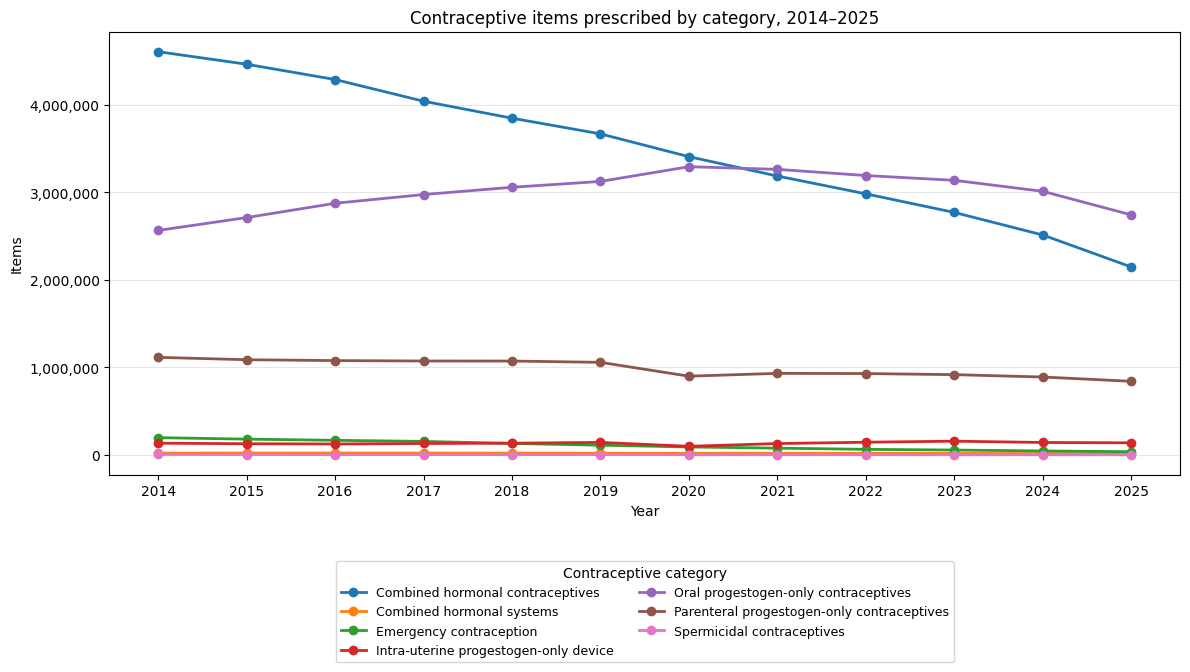

In [8]:
ax = items_by_category.plot(figsize=(12, 7), marker='o', linewidth=2)

ax.set_title('Contraceptive items prescribed by category, 2014–2025')
ax.set_xlabel('Year')
ax.set_ylabel('Items')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
ax.set_xticks(items_by_category.index)
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Contraceptive category', bbox_to_anchor=(0.5, -0.18),
          loc='upper center', ncol=2, fontsize=9)

plt.tight_layout()
plt.show()

Immediately, it is clear that the most significant reduction is in the combined hormonal contraceptives category, and this predates covid. 

### Are prescriptions getting bigger?
So far we've counted prescription items, but an item isn't a fixed amount of contraception. One item might be a 3-month supply, 6-month supply or even a year's supply. If practices have moved towards issuing larger quantities per prescription (which many did during the pandemic to reduce appointments), the number of items could fall without the amount of contraception supplied falling at all. To check this, we look at the average quantity per item for each category over time. 


In [9]:
sql_contraceptives_quantity_by_subparagraph = """
SELECT
  EXTRACT(YEAR FROM rx.month) AS year,
  bnf.subpara AS category,
  SUM(rx.items) AS items,
  SUM(rx.quantity) AS quantity
FROM `ebmdatalab.hscic.normalised_prescribing` AS rx
JOIN `ebmdatalab.hscic.bnf` AS bnf
  ON rx.bnf_code = bnf.presentation_code
WHERE month >= '2014-01-01' AND month < '2026-01-01'
  AND bnf_code LIKE '0703%'
GROUP BY year, category
ORDER BY year ASC, category
"""

contraceptives_quantity_by_subparagraph = bq.cached_read(
    sql_contraceptives_quantity_by_subparagraph,
    csv_path=os.path.join('..', 'data', 'contraceptives', 'contraceptives_quantity_by_subparagraph_2014_2025.csv')
)

In [10]:
display(contraceptives_quantity_by_subparagraph .head(10))

,year,category,items,quantity
0,2014,Combined hormonal contraceptives,4606974,444412806.0
1,2014,Combined hormonal systems,18837,72966.0
2,2014,Emergency contraception,195783,197653.0
3,2014,Intra-uterine progestogen-only device,132542,133556.0
4,2014,Oral progestogen-only contraceptives,2564088,303159388.0
5,2014,Parenteral progestogen-only contraceptives,1113565,1125423.0
6,2014,Spermicidal contraceptives,3627,327379.0
7,2015,Combined hormonal contraceptives,4463799,430619920.0
8,2015,Combined hormonal systems,19842,79625.0
9,2015,Emergency contraception,178921,180848.0


*Let's visualise this*  

NB: "quantity" means tablets for the oral categories but devices or injections for others. We will focus on trends alone

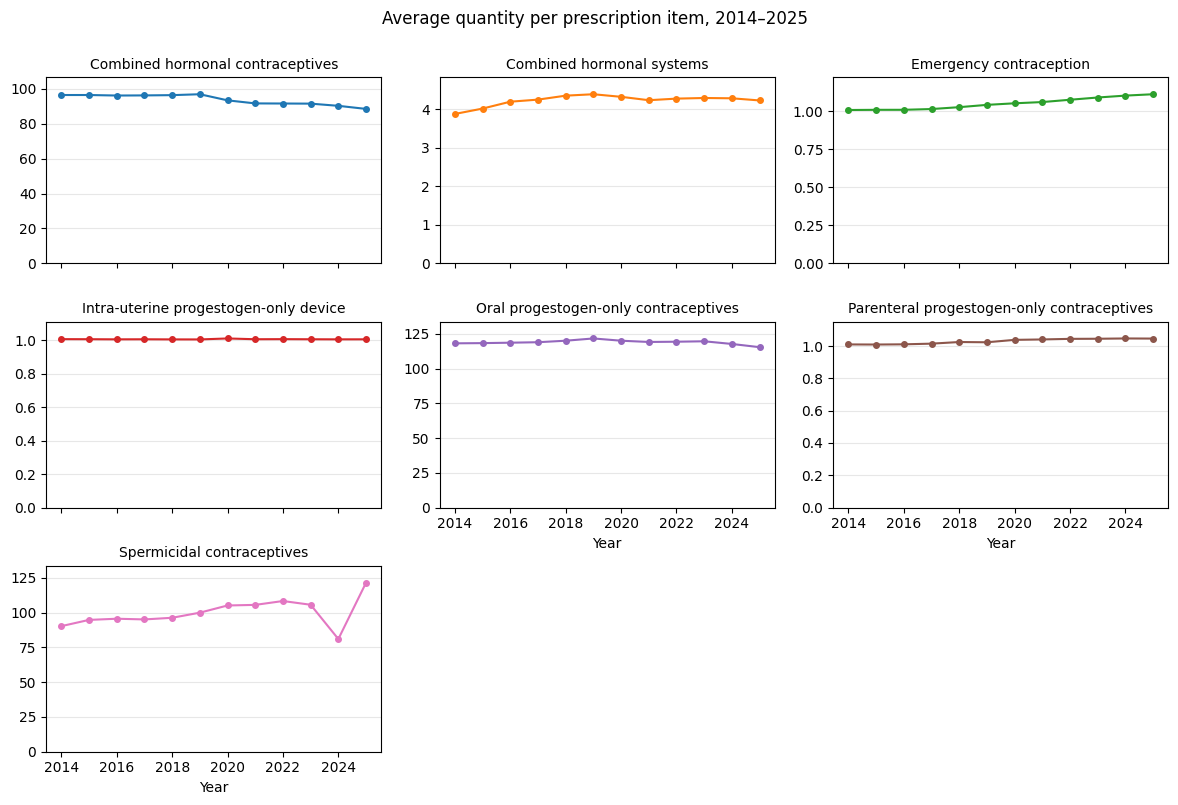

In [21]:
q = contraceptives_quantity_by_subparagraph.copy()

# Average quantity per prescription item, by year and category
q['quantity_per_item'] = q['quantity'] / q['items']

quantity_per_item = q.pivot(
    index='year',
    columns='category',
    values='quantity_per_item'
)

axes = quantity_per_item.plot(
    subplots=True,
    layout=(3, 3),          # More compact than 4 rows × 2 columns
    figsize=(12, 8),        # Reduce the overall height
    marker='o',
    markersize=4,
    linewidth=1.5,
    legend=False,
    sharex=True
)

for ax, cat in zip(axes.flat, quantity_per_item.columns):
    maximum = quantity_per_item[cat].max()

    ax.set_title(cat, fontsize=10)
    ax.set_ylim(0, maximum * 1.10)  # Start at 0 with 10% room above
    ax.grid(axis='y', alpha=0.3)
    ax.set_xlabel('Year')

# Hide any unused subplot
for ax in axes.flat[len(quantity_per_item.columns):]:
    ax.set_visible(False)

plt.suptitle(
    'Average quantity per prescription item, 2014–2025',
    y=1.0
)

plt.tight_layout()
plt.show()

If practices were in general prescribing larger quantites, the trend lines would be going upwards. As this isn'the case, the visuals confirm that bigger prescriptions are not masking the decline.

### A closer look at emergency contraception, month by month

Since emergency contraception is the category specifically flagged, we pull it out on its own at monthly resolution. This lets us see the shape of the pandemic period directly. Specifically to identify if there was  a spike, a dip, and does the decline since 2021 continue a trend that was already underway before 2020.

Emergency contraception has its own branch of the BNF hierarchy, so we can select it with codes starting `0703050`. The query is the same shape as before, just grouped by month instead of year.

In [12]:
sql_emergency_contraception_rx_monthly = """
SELECT
  month,
  SUM(items) AS items
FROM `ebmdatalab.hscic.normalised_prescribing`
WHERE month >= '2014-01-01' AND month < '2026-01-01'
  AND bnf_code LIKE '0703050%'
GROUP BY month
ORDER BY month
"""

emergency_contraception_rx_monthly = bq.cached_read(
    sql_emergency_contraception_rx_monthly,
    csv_path=os.path.join('..', 'data', 'contraceptives', 'emergency_contraception_rx_monthly_2014_2025.csv')
)

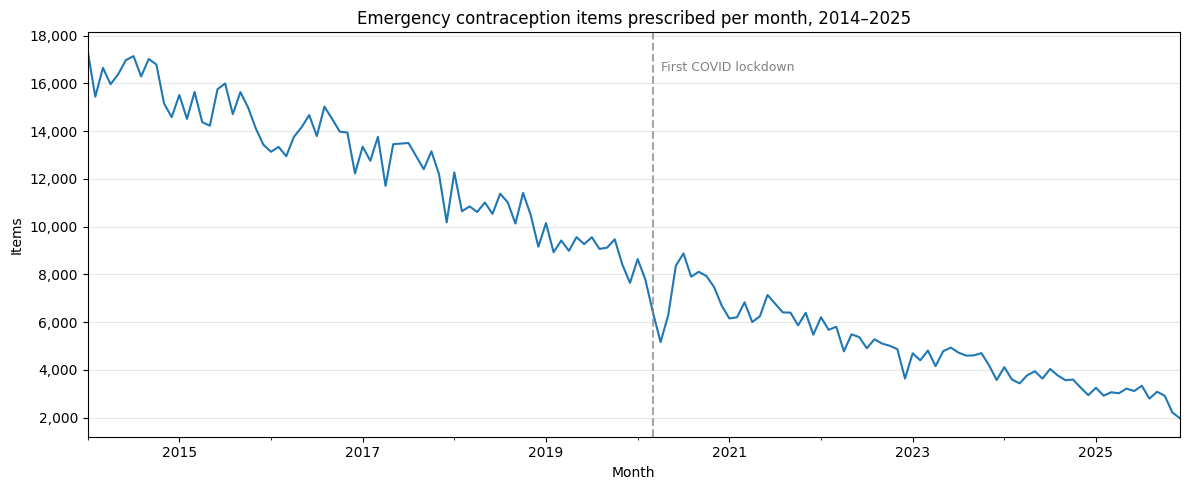

In [22]:
ec = emergency_contraception_rx_monthly.copy()
ec['month'] = pd.to_datetime(ec['month'])  # treat the month column as dates so the x-axis works properly

ax = ec.plot(x='month', y='items', figsize=(12, 5), linewidth=1.5, legend=False)

# Mark events that are useful reference points when reading the chart
ax.axvline(pd.Timestamp('2020-03-01'), color='grey', linestyle='--', alpha=0.7)
ax.text(pd.Timestamp('2020-04-01'), ec['items'].max() * 0.95, 'First COVID lockdown', color='grey', fontsize=9)

ax.set_title('Emergency contraception items prescribed per month, 2014–2025')
ax.set_xlabel('Month')
ax.set_ylabel('Items')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Key points

- Total contraceptive prescribing in English general practice has fallen substantially since 2014, driven mainly by a pre-pandemic decline in combined pills.
- The decline in emergency contraception is not a post-2021 phenomenon. GP-prescribed emergency contraception has been falling steadily since at least 2014.
  
**Crucially, these observations show a shrinking route, not shrinking use.**

During this period other alternative routes to contraception expanded, moving activity out of GP prescribing date, most notably, the NHS Pharmacy Contraception Service allowing community pharmacies to provide supplies of oral contraception without a GP prescription. These supplies are recorded in pharmacy service data, not in the prescribing dataset used here.

Emergency contraception was already the category *least* well captured by GP prescribing: it has been available to buy from pharmacies for over a decade and  many local authorities have long commissioned free pharmacy supply, and some provision happens in sexual health clinics. 

For a fuller picture, an analysis would need to integrate contraceptive data from these other routes. I have added a link to the data source where this information is available publicly. Public data sources exist for some of them:
-   [Sexual and reproductive health (SRH) services statistics](https://digital.nhs.uk/data-and-information/publications/statistical/sexual-and-reproductive-health-services) -clinic-provided contraception
-   [NHS Pharmacy Contraception Service data](https://opendata.nhsbsa.net/dataset/prescription-cost-analysis-pca-annual-statistics/resource/72fa5515-4740-40fe-8ee7-5cbc390720a0?filters=PHARMACY_ADVANCED_SERVICE%3ANHS%2520Pharmacy%2520Contraception%2520Service) -contraception supplied via NHS pharmacy advanced services

No routine public data currently covers contraception bought over the counter, supplied free under local authority pharmacy schemes or prescribed privately.




## End of notebook

*AI has been used to  write the python code for this notebook.*